# 2. Futures Backtesting and Implementation

If the earlier notes define a skeptical research stance and a disciplined strategy-development process, this note focuses on one of the markets where that discipline matters most in practice: futures. Futures are highly attractive for systematic trading because they offer standardized contracts, transparent exchange trading, broad asset-class coverage, and efficient access to directional or tactical exposure. At the same time, they are also easy to mishandle in research. Unlike equities, futures do not provide one permanent tradable object with a single uninterrupted price history. Contracts expire, liquidity migrates across maturities, rolls must be specified, and notional exposure changes through time.

For that reason, futures backtesting should begin with instrument mechanics and data construction rather than with signal design alone. Before asking whether a trading rule works, the researcher must define what is actually being traded, how that position is maintained through time, and how the research series relates to executable contracts.

## 2.1 Why futures require a different research mindset

A futures contract is a standardized agreement traded on an organized exchange, specifying a future transaction on a given underlying asset, with defined contract size, maturity, and settlement terms. Futures are central to systematic trading because they provide efficient access to equity indices, rates, commodities, currencies, and volatility-linked markets within a common implementation framework.

Their advantages are clear. They are often liquid, centrally cleared, operationally standardized, and naturally suited to rule-based exposure management. They also allow researchers to study broad macro and cross-asset ideas without constructing positions instrument by instrument in the underlying cash markets.

But these same advantages can create false simplicity. A stock can often be treated as one continuous tradable object. A futures contract cannot. It has a life cycle, loses relevance as expiration approaches, and must eventually be replaced by another contract if exposure is to be maintained. As a result, futures research is not only about signal quality; it is also about contract methodology, roll design, and execution realism.

## 2.2 Why futures cannot be treated like a single stock series

Because futures expire, the researcher is never working with one permanent tradable object. Instead, the strategy must decide which maturity matters, when liquidity shifts, and how exposure is maintained through time. The figures below illustrate why contract-level data must be understood before any backtest can be trusted.


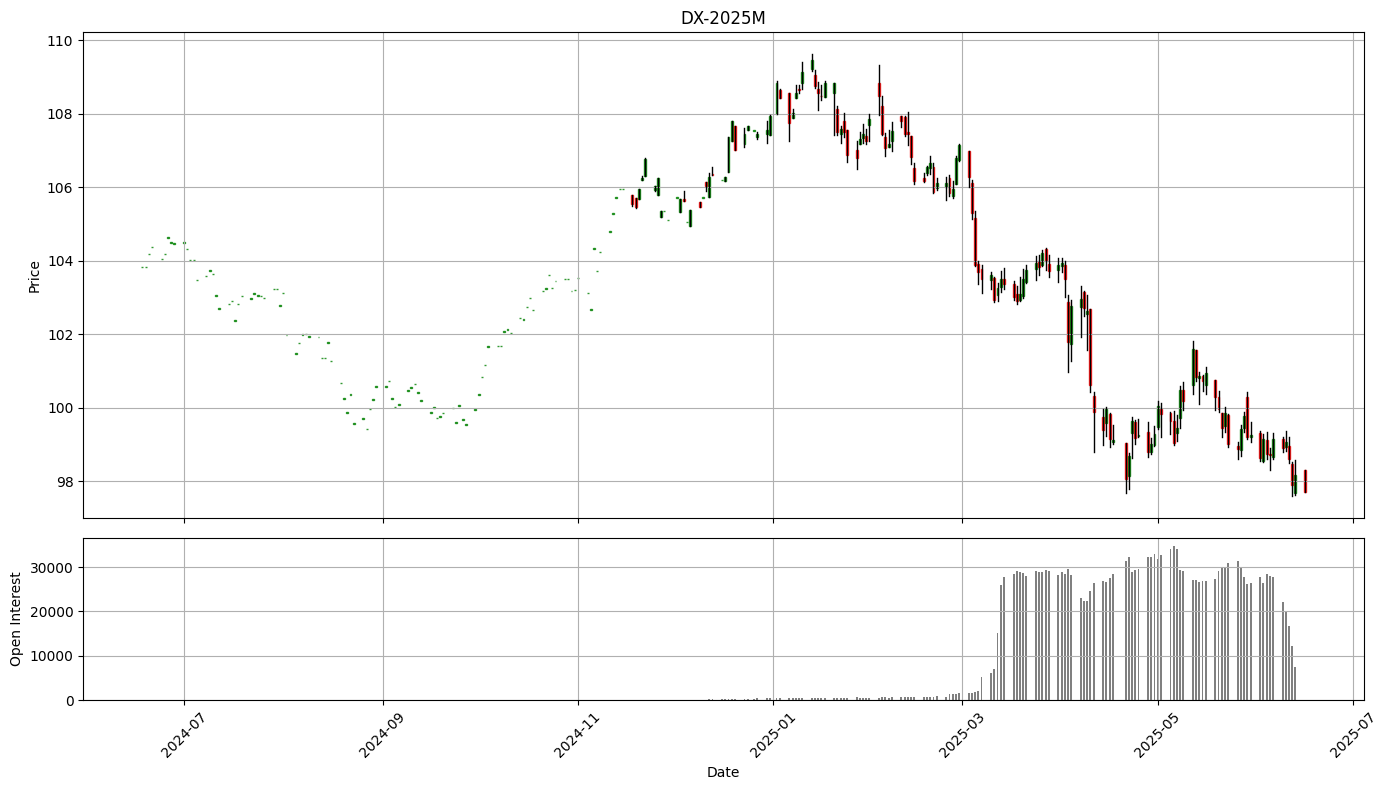

In [3]:
import norgatedata
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import pandas as pd

# Load data
symbol = 'DX-2025M'

df = norgatedata.price_timeseries(
    symbol,
    start_date='2020-01-01',
    end_date='2025-08-01',
    format='pandas-dataframe',
    stock_price_adjustment_setting=norgatedata.StockPriceAdjustmentType.NONE,
    padding_setting=norgatedata.PaddingType.NONE,
    timezone='UTC'
)

if df.empty:
    print(f"No data found for {symbol}")
else:
    # Drop rows with missing data
    df = df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Open Interest'])

    # Reset index to access date as column
    df = df.copy()
    df['Date'] = pd.to_datetime(df.index)
    df['DateNum'] = mdates.date2num(df['Date'])  # Convert to matplotlib date numbers

    # Create figure and subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # --- CANDLESTICKS ---
    width = 0.6  # Width of the candle bodies
    color_up = 'green'
    color_down = 'red'

    for idx, row in df.iterrows():
        color = color_up if row['Close'] >= row['Open'] else color_down
        # Wick (High-Low)
        ax1.plot([row['DateNum'], row['DateNum']], [row['Low'], row['High']], color='black', linewidth=1)
        # Body (Open-Close) 
        lower = min(row['Open'], row['Close'])
        height = abs(row['Close'] - row['Open'])
        candle = Rectangle(
            (row['DateNum'] - width / 2, lower),
            width,
            height if height > 0 else 0.01,  # Avoid zero-height candles
            color=color,
            alpha=0.8
        )
        ax1.add_patch(candle)

    ax1.set_ylabel('Price')
    ax1.set_title(f'{symbol}')
    ax1.grid(True)

    # --- OPEN INTEREST ---
    ax2.bar(df['DateNum'], df['Open Interest'], width=0.6, color='gray')
    ax2.set_ylabel('Open Interest')
    ax2.set_xlabel('Date')
    ax2.grid(True)

    # Format x-axis as dates
    ax2.xaxis_date()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


_Figure 1 Single Contract - DX2025M_

This figure shows the life of one individual futures contract. The important point is that a contract is only meaningful while it is active and liquid. A futures strategy therefore cannot assume one uninterrupted price series in the same way as an equity backtest. Any analysis based on a single contract will eventually run into the fact that the instrument disappears.


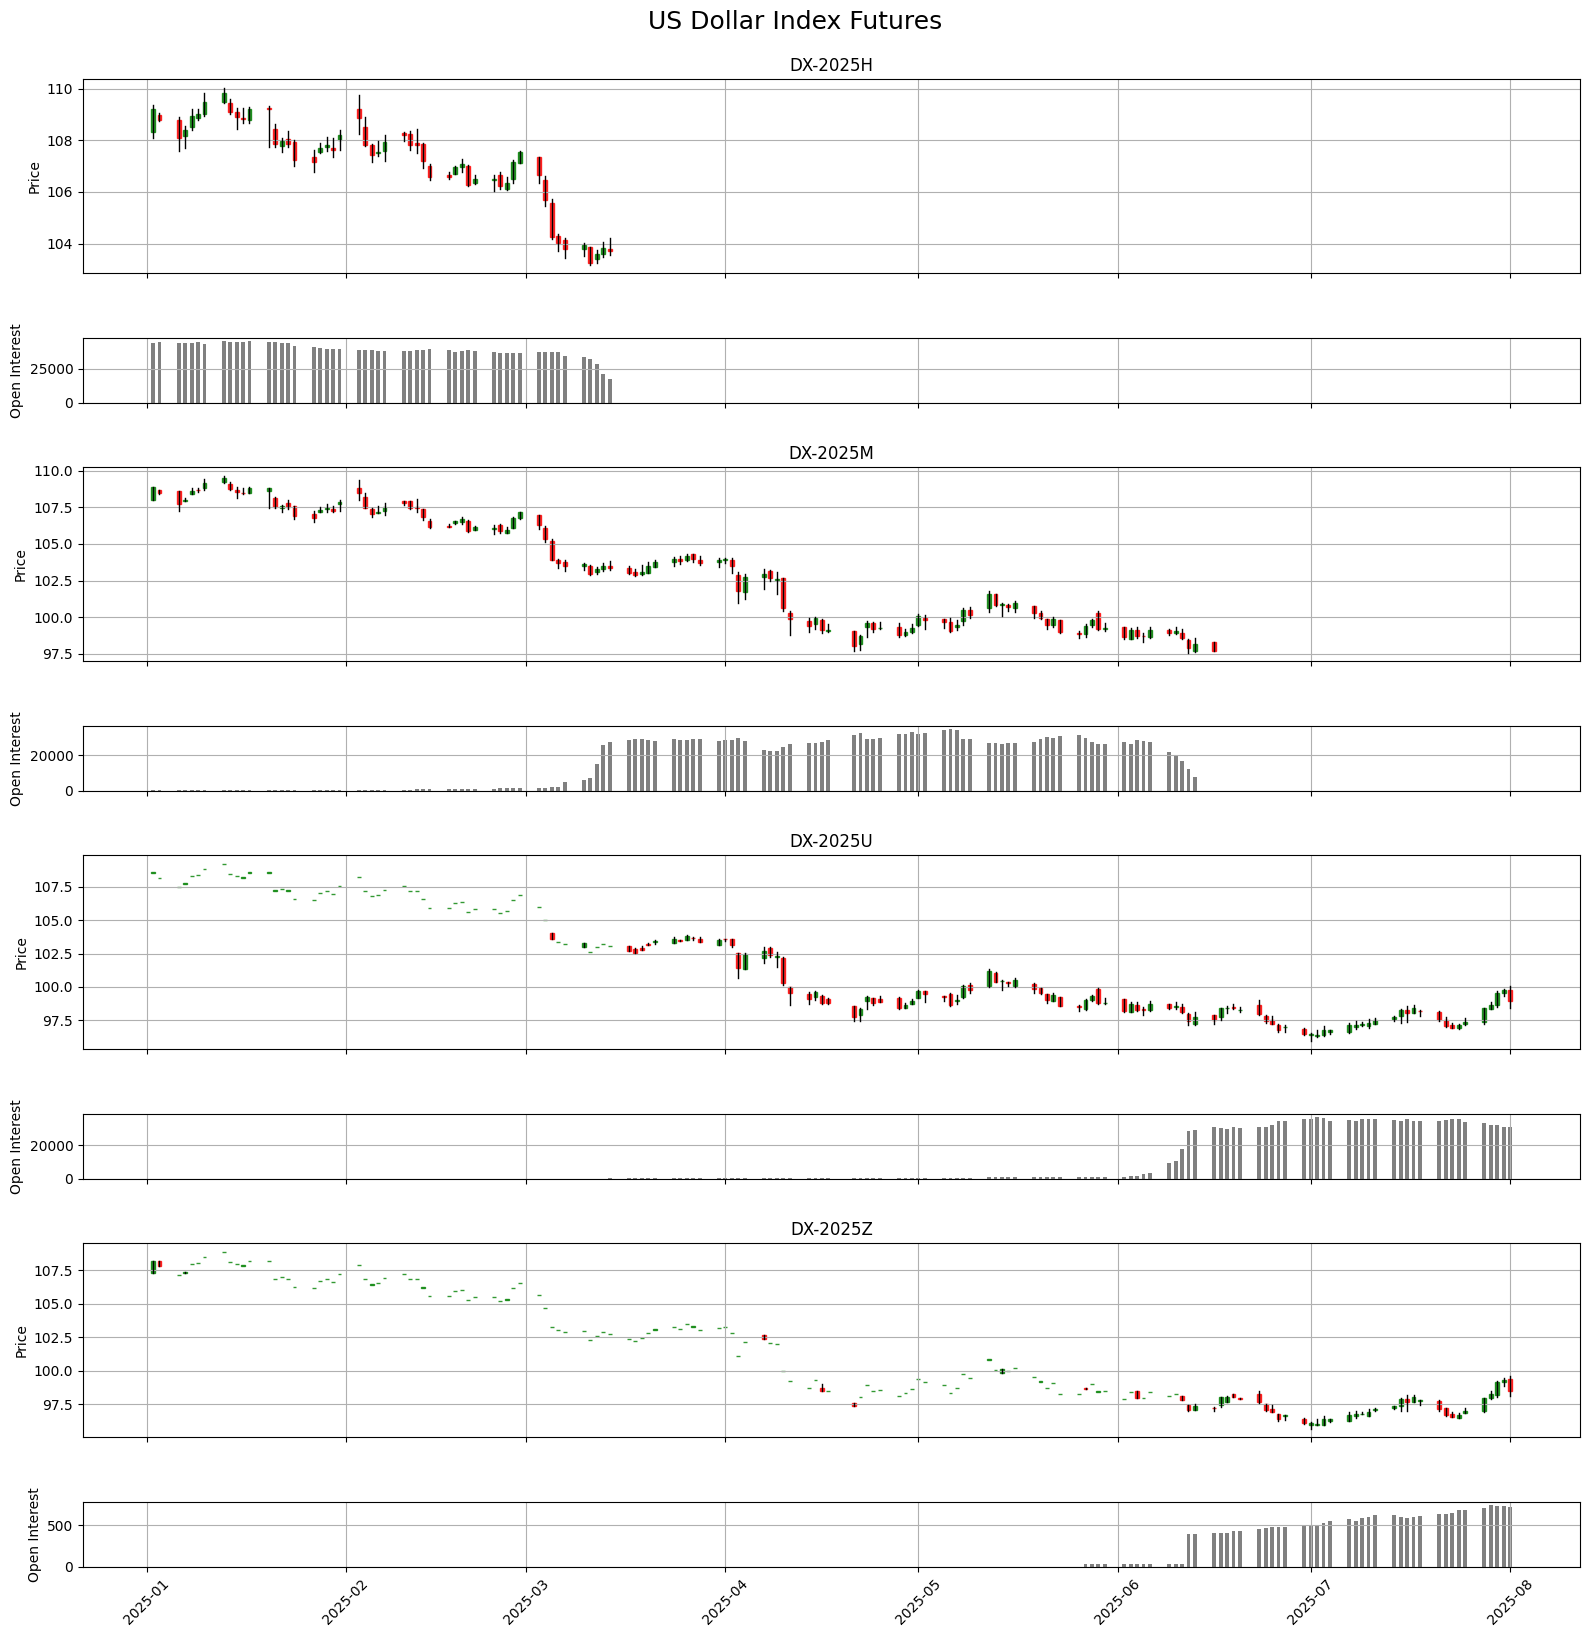

In [4]:
import norgatedata
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import pandas as pd

# Define your contract symbols
symbols = ['DX-2025H', 'DX-2025M', 'DX-2025U', 'DX-2025Z']
start_date = '2025-01-01'

# Matplotlib settings
plt.style.use('default')
fig, axes = plt.subplots(len(symbols) * 2, 1, figsize=(16, 16), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1] * len(symbols)})

for i, symbol in enumerate(symbols):
    # Fetch data
    df = norgatedata.price_timeseries(
        symbol,
        start_date=start_date,
        end_date='2025-08-01',
        format='pandas-dataframe',
        stock_price_adjustment_setting=norgatedata.StockPriceAdjustmentType.NONE,
        padding_setting=norgatedata.PaddingType.NONE,
        timezone='UTC'
    )

    if df.empty:
        print(f"No data for {symbol}")
        continue

    # Prepare data
    df = df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Open Interest']).copy()
    df['Date'] = pd.to_datetime(df.index)
    df['DateNum'] = mdates.date2num(df['Date'])

    # Axes for price and OI
    ax_price = axes[i * 2]
    ax_oi = axes[i * 2 + 1]

    # Plot candlesticks
    width = 0.6
    for _, row in df.iterrows():
        color = 'green' if row['Close'] >= row['Open'] else 'red'
        # Wick
        ax_price.plot([row['DateNum'], row['DateNum']], [row['Low'], row['High']], color='black', linewidth=1)
        # Body
        body = Rectangle(
            (row['DateNum'] - width / 2, min(row['Open'], row['Close'])),
            width,
            max(abs(row['Close'] - row['Open']), 0.01),
            color=color,
            alpha=0.8
        )
        ax_price.add_patch(body)

    ax_price.set_ylabel('Price')
    ax_price.set_title(f'{symbol}')
    ax_price.grid(True)

    # Plot Open Interest
    ax_oi.bar(df['DateNum'], df['Open Interest'], width=0.6, color='gray')
    ax_oi.set_ylabel('Open Interest')
    ax_oi.grid(True)

# Format date axis
axes[-1].xaxis_date()
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.suptitle('US Dollar Index Futures', fontsize=18, y=1.02)
plt.subplots_adjust(hspace=0.5)
plt.show()


_Figure 2 Liquidity Moving from Contract to Contract_

Liquidity does not remain constant across the futures curve. It tends to migrate from the expiring contract into the next active maturity according to a market-specific cycle. From a modeling perspective, this means that the relevant tradable object changes over time. A researcher may still observe prices in older or less active maturities, but those prices may be much less relevant for realistic execution.

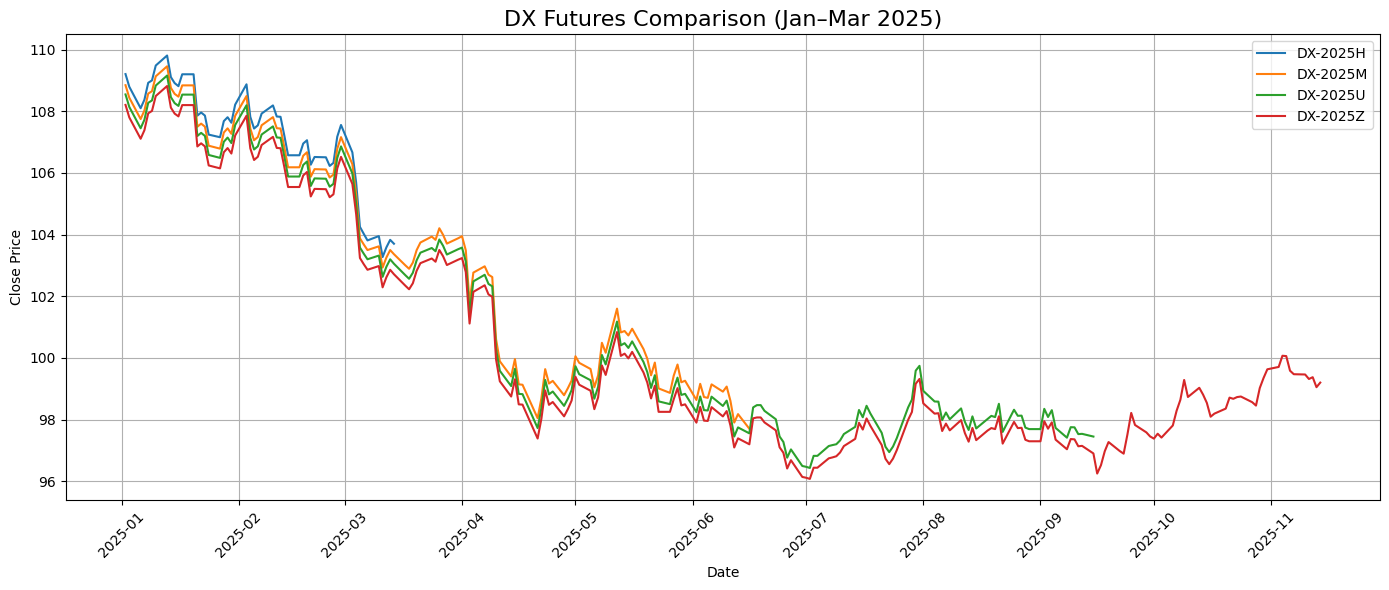

In [6]:
import norgatedata
import matplotlib.pyplot as plt
import pandas as pd

# Define contract symbols
symbols = ['DX-2025H', 'DX-2025M', 'DX-2025U', 'DX-2025Z']
start_date = '2025-01-01'
end_date = '2025-11-16'

# Create figure
plt.figure(figsize=(14, 6))

for symbol in symbols:
    # Fetch data
    df = norgatedata.price_timeseries(
        symbol,
        start_date=start_date,
        end_date=end_date,
        format='pandas-dataframe',
        stock_price_adjustment_setting=norgatedata.StockPriceAdjustmentType.NONE,
        padding_setting=norgatedata.PaddingType.NONE,
        timezone='UTC'
    )

    if df.empty:
        print(f"No data found for {symbol}")
        continue

    # Drop missing values and plot Close price
    df = df.dropna(subset=['Close'])
    plt.plot(df.index, df['Close'], label=symbol)

# Formatting
plt.title('DX Futures Comparison (Jan–Mar 2025)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


_Figure 3 Comparing Contracts_

Contracts on the same underlying can trade at different prices because of carry, storage, funding, interest-rate effects, or other term-structure forces. This matters because a signal built from one maturity may not translate mechanically into another. A backtest that ignores these differences risks confusing the behavior of the underlying asset with the behavior of a specific point on the futures curve.

## 2.3 From individual contracts to continuation series

Once contract-level behavior is understood, the next challenge is building a usable research series. Simply stitching contracts together creates artificial jumps around roll dates, while adjusted continuations solve some problems but introduce their own interpretation issues. The goal is not to find a perfect series, but to choose one that matches the research question without distorting execution reality.

Researchers often create continuous futures series because long-horizon backtesting requires something more stable than a sequence of expiring contracts. These series are useful, but they are synthetic. They are research devices rather than direct tradable instruments.

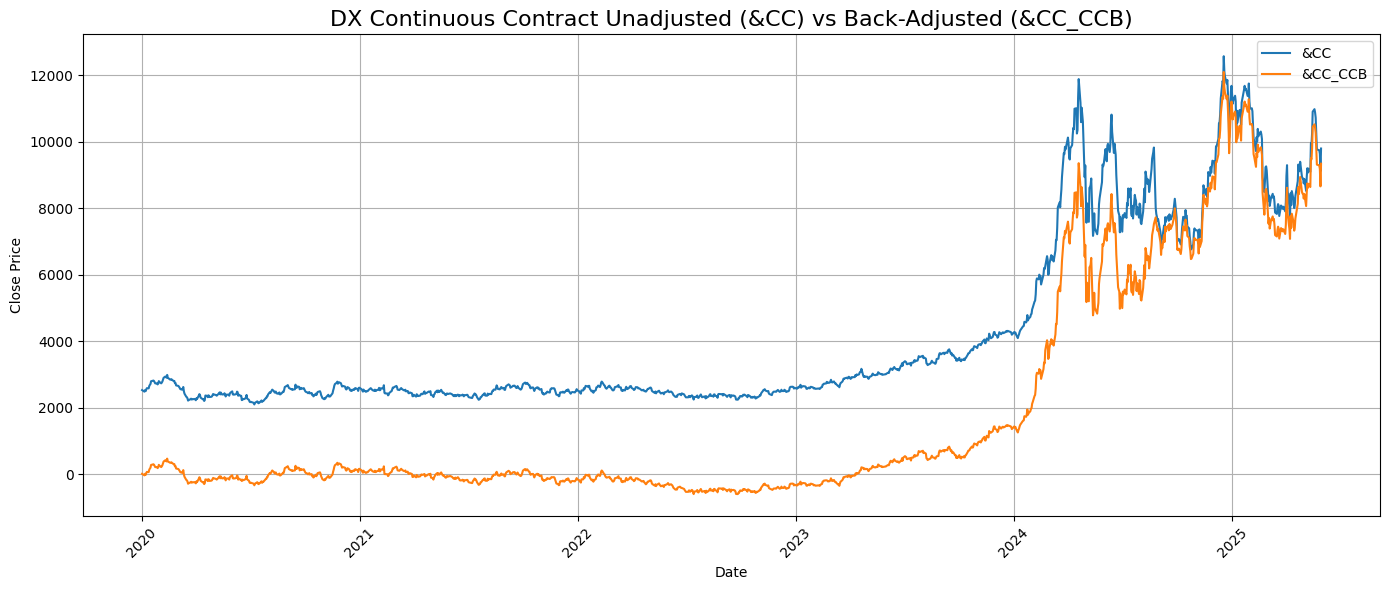

In [7]:
import norgatedata
import matplotlib.pyplot as plt
import pandas as pd

# Set date range
start_date = '2020-01-01'
end_date = '2025-06-01'

# Symbols to compare
symbols = ['&CC', '&CC_CCB']

# Create figure
plt.figure(figsize=(14, 6))

for symbol in symbols:
    # Fetch data
    df = norgatedata.price_timeseries(
        symbol,
        start_date=start_date,
        end_date=end_date,
        format='pandas-dataframe',
        stock_price_adjustment_setting=norgatedata.StockPriceAdjustmentType.NONE,  # Not needed for continuous contracts
        padding_setting=norgatedata.PaddingType.NONE,
        timezone='UTC'
    )

    if df.empty:
        print(f"No data for {symbol}")
        continue

    # Plot closing price
    plt.plot(df.index, df['Close'], label=symbol)

# Formatting
plt.title('DX Continuous Contract Unadjusted (&CC) vs Back-Adjusted (&CC_CCB)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


_Figure 4 Unadjusted versus Back-Adjusted Continuation_

A raw stitched series preserves observed contract prices but typically introduces visible jumps when the active contract changes. Those jumps may contaminate trend indicators, return calculations, and volatility estimates if they are treated as genuine market moves. Adjusted continuations smooth those transitions and are often more useful for signal construction, but they achieve that by altering the historical price path. The resulting series is analytically convenient, not literally tradable.

This distinction is central. The question is not whether one continuation method is universally correct, but whether the chosen series is consistent with the economic and implementation question being studied. A signal derived from a synthetic continuation may still be useful, but the researcher must remain aware that live execution will occur in actual contracts.


## 2.4 Rolls are part of the strategy, not a data inconvenience

Rolling from one contract to the next is not merely an operational afterthought. It is part of the realized strategy. A roll decision affects transaction timing, execution cost, continuity of exposure, and in some markets the economic return itself. This is especially important in futures strategies where carry, basis, or curve shape contribute materially to performance.

For that reason, a futures backtest should specify:

- which contract is considered active,
- what event or date triggers the roll,
- whether the roll is assumed at the open, close, settlement, or across multiple sessions,
- and how the roll convention in research relates to executable behavior.

A strategy that appears smooth only because roll mechanics are hidden in a synthetic series is not necessarily robust. Good futures research makes the roll logic explicit.

## 2.5 Price return is not the whole return

A futures position generates marked-to-market profit and loss through changes in contract price, but the economic return of a futures strategy is not always captured by price movement alone. Because futures are margined instruments, capital not tied up in margin may remain in cash or collateral, and depending on the design of the backtest that capital may itself earn a return.

Similarly, some strategies are about more than the directional move of the underlying. Curve trades, carry-oriented strategies, and volatility-related strategies are often sensitive to the interaction between price movement, term structure, and capital usage. This means the researcher should define clearly whether the backtest is measuring contract-level PnL, excess return, or total portfolio return.

That distinction matters because otherwise a strategy may appear stronger or weaker simply because the definition of return has changed.

## 2.6 Notional exposure matters more than contract count

In futures, the number of contracts held is rarely the most informative measure of risk. What matters is the notional exposure implied by those contracts and how that exposure scales relative to portfolio capital, volatility, and margin usage.

For a futures contract with price $P_t$ and multiplier $m$, the notional value of one contract is

$$
N_t = P_t \times m.
$$

If the strategy holds $q_t$ contracts, total notional exposure is

$$
E_t = q_t \times P_t \times m.
$$

This means that the same contract count can represent very different economic exposure across markets and across time. A single equity index futures contract does not imply the same risk as a single rates contract or commodity contract, and even within one market the risk of a fixed contract count changes as prices and volatility evolve.

For that reason, futures strategies are usually interpreted through notional, volatility, or portfolio-weight terms rather than through contract count alone.

## 2.7 Leverage should be modeled explicitly

Futures make leverage operationally easy, but that does not make it secondary. On the contrary, leverage is one of the main reasons futures backtests can look attractive while becoming fragile in live trading.

A strategy with moderate signal quality can be transformed into an apparently impressive return stream if the backtest assumes unconstrained scaling, ignores volatility spikes, or fails to consider drawdown tolerance. This is particularly important in overlays, low-volatility strategies, or any framework that adjusts exposure dynamically.

Leverage should therefore be treated as an explicit modeling choice. The researcher should define how exposure is set, what constraints apply, whether volatility targeting is used, and what happens when volatility rises sharply or market conditions deteriorate. In a disciplined process, scaling is not cosmetic. It is part of the strategy itself.

## 2.8 From research series to tradable execution

A continuation series may be useful for signal generation, but it is not itself a tradable instrument. For realistic backtesting, the strategy must still decide how positions are rolled in actual contracts. The implementation below shows how this distinction is handled in practice: indicators are computed on the continuation logic, while orders are executed on the active underlying contract.

_Insert your code block and any supporting graph here._

This is the practical bridge between research and deployment. The signal may be based on a cleaned or adjusted research series, but the orders must still be mapped onto a live contract with real specifications, real expiration, and real execution timing. A futures strategy becomes credible only when this mapping is explicit.

## 2.9 Timing conventions can create false precision

Many backtesting mistakes come from subtle mismatches between when information is known and when a trade is assumed to occur. This is especially important in futures because the data may be observed in one convention while the strategy is assumed to execute in another.

If a signal is computed from end-of-day settlement data, can the strategy realistically trade at that same settlement price? Usually not. If the rule depends on volume, final settlement, or end-of-session information, then the trade should generally be assumed no earlier than the next executable opportunity.

A realistic futures backtest should therefore define the sequence clearly:

1. what information is known,
2. when the signal is computed,
3. when the order is sent,
4. and what fill assumption is applied.

Without that sequencing, the backtest may gain performance from timing assumptions that are not operationally available in live trading.

## 2.10 Transaction costs and slippage are market-specific

Futures are often efficient instruments to trade, but they are not costless. Fees, spreads, roll friction, and slippage vary materially across markets and sometimes across regimes. A strategy that trades infrequently in a very liquid equity index future faces a different cost environment from one that trades more actively in a thinner commodity or volatility-linked contract.

A useful futures backtest should therefore account for:

- exchange and brokerage fees,
- bid-ask spreads,
- slippage under realistic trading conditions,
- roll costs,
- and any market-specific frictions relevant to the instrument.

The purpose is not to estimate every cost perfectly. It is to avoid the fiction of frictionless execution. Sensitivity analysis is especially valuable here: a strategy that remains coherent under somewhat worse cost assumptions is usually more credible than one whose performance disappears after a small increase in friction.

## 2.11 Benchmarks should match the role of the strategy

A futures strategy should not be judged in isolation. The relevant question is usually not whether it made money, but whether it improved on a simpler or more appropriate alternative.

Examples include:

- passive long exposure as a benchmark for directional index futures timing,
- constant-notional exposure for a volatility-targeting overlay,
- a simpler trend rule for a more complex signal,
- or an equal-risk baseline for a diversified futures portfolio.

Benchmarks help separate genuine improvement from repackaged market exposure, leverage, or favorable sample conditions. In a skeptical research framework, benchmark choice is part of the test, not an afterthought.

## 2.12 Futures backtesting is about structure, not just performance

The central lesson of futures research is that apparent performance often depends on hidden structural choices. Continuous-series construction, roll timing, sizing rules, leverage assumptions, and execution conventions all influence the result. A chart alone does not reveal whether those choices were realistic.

For that reason, good futures backtesting is less about producing the most attractive historical return stream and more about building a transparent structure in which the result can be interpreted. The researcher should know what is being traded, how it is maintained through time, how it is scaled, and how the research logic connects to executable trading.

This is why futures fit naturally after the earlier notes on skepticism and disciplined strategy development. If markets are competitive and if backtests are easy to overstate, then futures demand especially careful handling. When treated casually, they produce some of the most misleading results in applied finance. When treated carefully, they provide one of the best environments for systematic research, implementation, and honest evaluation.
